# **3. Normal Distribution & Z-Scores**

## The Normal Distribution
The **normal distribution** (Gaussian distribution) is the most important distribution in statistics.

### PDF Formula
$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

### Properties
- **Bell-shaped** and symmetric around μ
- Mean = Median = Mode
- Defined by two parameters: μ (mean) and σ (std dev)
- Area under curve = 1

## The 68-95-99.7 Rule (Empirical Rule)

| Range | % of Data |
|-------|----------|
| μ ± 1σ | 68.27% |
| μ ± 2σ | 95.45% |
| μ ± 3σ | 99.73% |

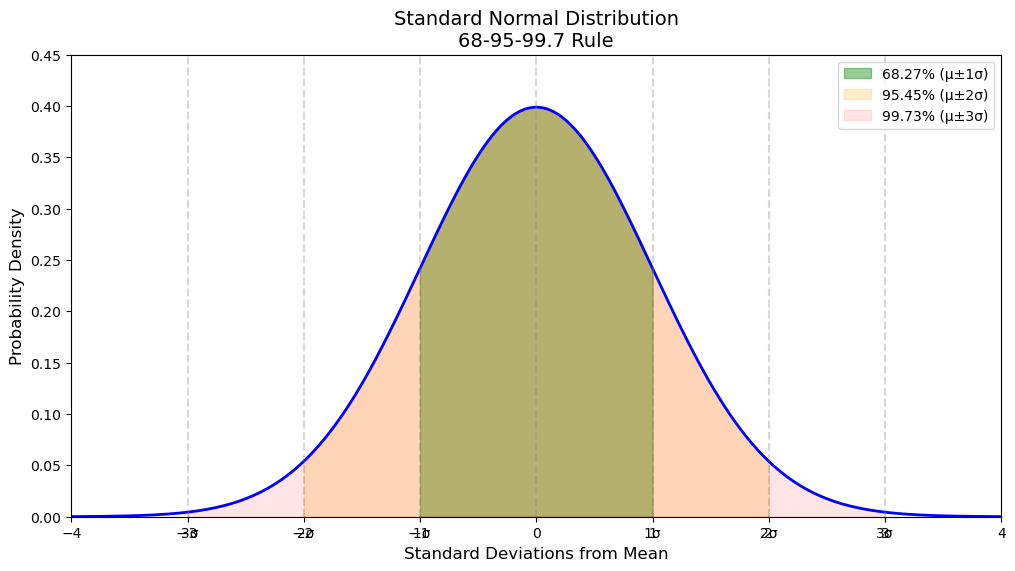

In [1]:
# ===============================================
# NORMAL DISTRIBUTION VISUALIZATION
# ===============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Standard normal: μ=0, σ=1
x = np.linspace(-4, 4, 200)
y = stats.norm.pdf(x, 0, 1)

fig, ax = plt.subplots(figsize=(12, 6))

# Plot the curve
ax.plot(x, y, 'b-', linewidth=2)

# Shade 68-95-99.7 regions
x_1sigma = np.linspace(-1, 1, 100)
ax.fill_between(x_1sigma, stats.norm.pdf(x_1sigma), alpha=0.4, color='green', label='68.27% (μ±1σ)')

x_2sigma = np.linspace(-2, 2, 100)
ax.fill_between(x_2sigma, stats.norm.pdf(x_2sigma), alpha=0.2, color='orange', label='95.45% (μ±2σ)')

x_3sigma = np.linspace(-3, 3, 100)
ax.fill_between(x_3sigma, stats.norm.pdf(x_3sigma), alpha=0.1, color='red', label='99.73% (μ±3σ)')

# Add sigma markers
for i in range(-3, 4):
    ax.axvline(x=i, color='gray', linestyle='--', alpha=0.3)
    if i != 0:
        ax.text(i, -0.02, f'{i}σ', ha='center', fontsize=10)

ax.set_xlabel('Standard Deviations from Mean', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title('Standard Normal Distribution\n68-95-99.7 Rule', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
ax.set_xlim(-4, 4)
ax.set_ylim(0, 0.45)
plt.show()

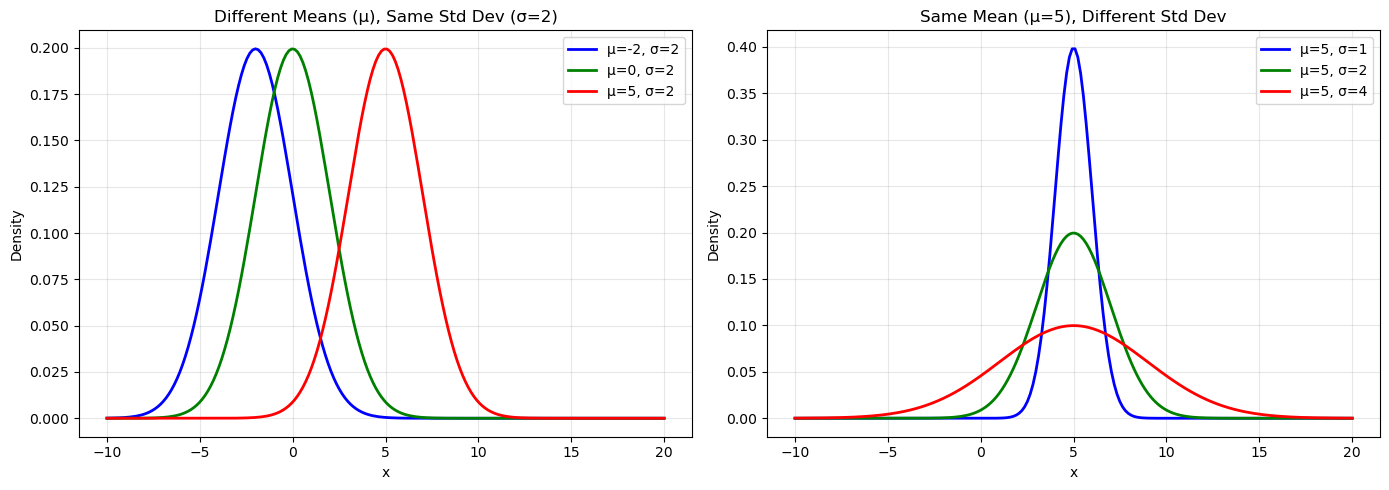

Key Insights:
  - μ shifts the distribution left/right
  - σ controls the spread (larger σ = flatter curve)


In [2]:
# ===============================================
# DIFFERENT NORMAL DISTRIBUTIONS
# ===============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.linspace(-10, 20, 200)

# Plot 1: Different means, same std dev
ax1 = axes[0]
for mu, color in [(-2, 'blue'), (0, 'green'), (5, 'red')]:
    ax1.plot(x, stats.norm.pdf(x, mu, 2), color=color, linewidth=2, 
             label=f'μ={mu}, σ=2')
ax1.set_title('Different Means (μ), Same Std Dev (σ=2)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('x')
ax1.set_ylabel('Density')

# Plot 2: Same mean, different std dev
ax2 = axes[1]
for sigma, color in [(1, 'blue'), (2, 'green'), (4, 'red')]:
    ax2.plot(x, stats.norm.pdf(x, 5, sigma), color=color, linewidth=2, 
             label=f'μ=5, σ={sigma}')
ax2.set_title('Same Mean (μ=5), Different Std Dev')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('x')
ax2.set_ylabel('Density')

plt.tight_layout()
plt.show()

print("Key Insights:")
print("  - μ shifts the distribution left/right")
print("  - σ controls the spread (larger σ = flatter curve)")

---
# **Z-Scores (Standard Scores)**

A **Z-score** tells you how many standard deviations a value is from the mean.

## Formula
$$z = \frac{x - \mu}{\sigma}$$

## Interpretation
| Z-Score | Meaning |
|---------|--------|
| z = 0 | At the mean |
| z = 1 | 1 std dev above mean |
| z = -2 | 2 std devs below mean |

## Why Z-Scores are Useful
- **Standardization**: Compare values from different distributions
- **Identify Outliers**: |z| > 2 or 3 are unusual
- **Probability Calculation**: Use standard normal tables

In [ ]:
# ===============================================
# Z-SCORE CALCULATIONS
# ===============================================

import numpy as np
from scipy import stats

print("=" * 50)
print("Z-SCORE CALCULATIONS")
print("=" * 50)

# Example: Test scores with mean=75, std=10
mu = 75
sigma = 10

print(f"\nTest scores: μ = {mu}, σ = {sigma}")

# Calculate Z-scores for different scores
scores = [60, 75, 85, 95]

print("\nScore → Z-score → Interpretation:")
for score in scores:
    z = (score - mu) / sigma
    percentile = stats.norm.cdf(z) * 100
    print(f"  {score} → z = {z:+.1f} → {percentile:.1f}th percentile")

# Reverse: Z-score to raw score
print("\n" + "-" * 50)
print("Reverse: What score is at the 90th percentile?")

z_90 = stats.norm.ppf(0.90)
score_90 = mu + z_90 * sigma
print(f"  z at 90th percentile: {z_90:.2f}")
print(f"  Score: μ + z×σ = {mu} + {z_90:.2f}×{sigma} = {score_90:.1f}")

Z-SCORE CALCULATIONS

Test scores: μ = 75, σ = 10

Score → Z-score → Interpretation:
  60 → z = -1.5 → 6.7th percentile
  75 → z = +0.0 → 50.0th percentile
  85 → z = +1.0 → 84.1th percentile
  95 → z = +2.0 → 97.7th percentile

--------------------------------------------------
Reverse: What score is at the 90th percentile?
  z at 90th percentile: 1.28
  Score: μ + z×σ = 75 + 1.28×10 = 87.8


In [4]:
# ===============================================
# COMPARING ACROSS DISTRIBUTIONS WITH Z-SCORES
# ===============================================

print("=" * 50)
print("COMPARING SCORES FROM DIFFERENT TESTS")
print("=" * 50)

# Student A: SAT Math score = 720 (μ=500, σ=100)
# Student B: ACT Math score = 32 (μ=21, σ=5)
# Who did relatively better?

print("\nStudent A: SAT Math = 720")
print("  SAT distribution: μ=500, σ=100")
z_A = (720 - 500) / 100
print(f"  Z-score = (720-500)/100 = {z_A:.2f}")

print("\nStudent B: ACT Math = 32")
print("  ACT distribution: μ=21, σ=5")
z_B = (32 - 21) / 5
print(f"  Z-score = (32-21)/5 = {z_B:.2f}")

print("\n" + "=" * 50)
if z_A > z_B:
    print(f"🏆 Student A did relatively better!")
else:
    print(f"🏆 Student B did relatively better!")
print(f"   (Higher z-score = further above the mean)")

COMPARING SCORES FROM DIFFERENT TESTS

Student A: SAT Math = 720
  SAT distribution: μ=500, σ=100
  Z-score = (720-500)/100 = 2.20

Student B: ACT Math = 32
  ACT distribution: μ=21, σ=5
  Z-score = (32-21)/5 = 2.20

🏆 Student B did relatively better!
   (Higher z-score = further above the mean)


CDF (CUMULATIVE DISTRIBUTION FUNCTION)

Standard Normal CDF: P(Z ≤ z)
  P(Z ≤ -2) = 0.0228 (2.28%)
  P(Z ≤ -1) = 0.1587 (15.87%)
  P(Z ≤ +0) = 0.5000 (50.00%)
  P(Z ≤ +1) = 0.8413 (84.13%)
  P(Z ≤ +2) = 0.9772 (97.72%)

Inverse CDF (ppf): Percentile → Z-score
  5th percentile → z = -1.64
  25th percentile → z = -0.67
  50th percentile → z = +0.00
  75th percentile → z = +0.67
  95th percentile → z = +1.64


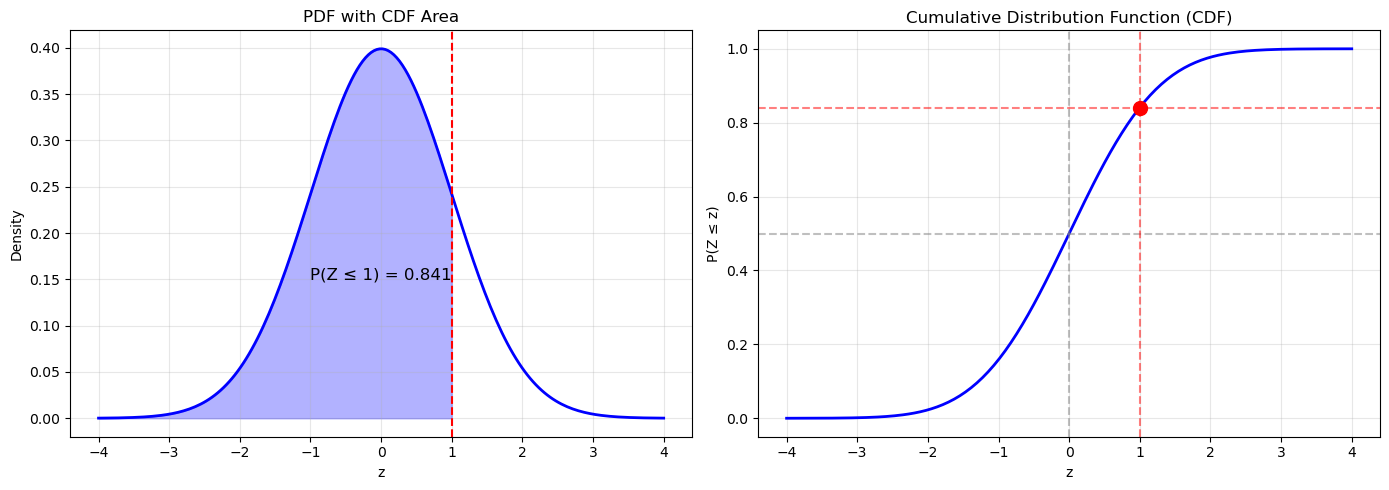

In [5]:
# ===============================================
# CDF AND INVERSE CDF
# ===============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

print("=" * 50)
print("CDF (CUMULATIVE DISTRIBUTION FUNCTION)")
print("=" * 50)

# CDF gives P(X ≤ x)
print("\nStandard Normal CDF: P(Z ≤ z)")
for z in [-2, -1, 0, 1, 2]:
    prob = stats.norm.cdf(z)
    print(f"  P(Z ≤ {z:+d}) = {prob:.4f} ({prob*100:.2f}%)")

# Inverse CDF (percentile to z-score)
print("\nInverse CDF (ppf): Percentile → Z-score")
for p in [0.05, 0.25, 0.50, 0.75, 0.95]:
    z = stats.norm.ppf(p)
    print(f"  {p*100:.0f}th percentile → z = {z:+.2f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.linspace(-4, 4, 200)

# Plot 1: PDF with shaded area
ax1 = axes[0]
ax1.plot(x, stats.norm.pdf(x), 'b-', linewidth=2)
x_fill = np.linspace(-4, 1, 100)
ax1.fill_between(x_fill, stats.norm.pdf(x_fill), alpha=0.3, color='blue')
ax1.axvline(x=1, color='red', linestyle='--')
ax1.text(0, 0.15, f'P(Z ≤ 1) = 0.841', fontsize=12, ha='center')
ax1.set_title('PDF with CDF Area')
ax1.set_xlabel('z')
ax1.set_ylabel('Density')
ax1.grid(True, alpha=0.3)

# Plot 2: CDF
ax2 = axes[1]
ax2.plot(x, stats.norm.cdf(x), 'b-', linewidth=2)
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax2.axhline(y=0.841, color='red', linestyle='--', alpha=0.5)
ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(x=1, color='red', linestyle='--', alpha=0.5)
ax2.scatter([1], [0.841], color='red', s=100, zorder=5)
ax2.set_title('Cumulative Distribution Function (CDF)')
ax2.set_xlabel('z')
ax2.set_ylabel('P(Z ≤ z)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Summary

| Concept | Formula/Usage |
|---------|---------------|
| **Normal PDF** | Defined by μ and σ |
| **68-95-99.7 Rule** | Data within 1, 2, 3 std devs |
| **Z-Score** | $z = \frac{x - \mu}{\sigma}$ |
| **CDF** | P(X ≤ x), `stats.norm.cdf(z)` |
| **Inverse CDF** | Percentile to value, `stats.norm.ppf(p)` |